# Логистическая регрессия

### Задача 1: Классификация ирисов Фишера (Многоклассовая логистическая регрессия)

Хотя логистическая регрессия бинарна, её можно расширить на несколько классов (стратегия One-vs-Rest).

- **Датасет:** Встроенный в sklearn (`sklearn.datasets.load_iris`).
- **Что нужно сделать:**
    1. Загрузить данные. Оставить только два класса для начала (например, Setosa и Versicolor), чтобы задача стала бинарной.
    2. Построить scatter-plot по двум признакам: длина чашелистика (`sepal length`) и длина лепестка (`petal length`). Выделить классы цветом. Визуально посмотреть, можно ли провести разделяющую прямую.
    3. Обучить `LogisticRegression`.
    4. Вывести коэффициенты $w_1, w_2$ и $w_0$.
    5. Используя эти коэффициенты, нарисовать на графике разделяющую прямую (Decision Boundary), решив уравнение $w_0 + w_1x_1 + w_2x_2 = 0$.

In [244]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

iris = sklearn.datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [245]:
x = iris.data
y = iris.target

Text(0.5, 1.0, 'Iris: Setosa vs Versicolor')

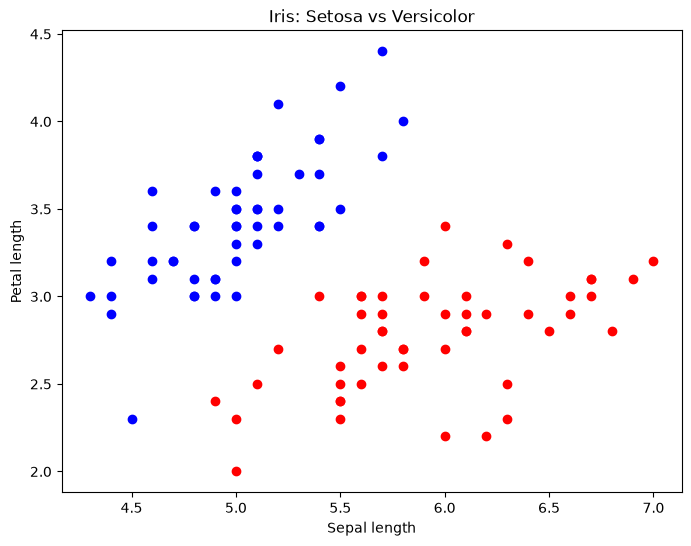

In [246]:
plt.figure(figsize=(8,6))

plt.scatter(
    x[y == 0, 0],
    x[y == 0, 1],
    color='blue',
    label='Setosa'
)

plt.scatter(
    x[y == 1, 0],
    x[y == 1, 1],
    color='red',
    label='Versicolor'
)

plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.title("Iris: Setosa vs Versicolor")

In [247]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [248]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(solver='lbfgs', max_iter=200)

lr_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [249]:
predictions = lr_model.predict(X_test)

In [250]:
print("Predictions: ", predictions)
print("Actual: ", y_test)

Predictions:  [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual:  [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [251]:
train_accuracy = lr_model.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

test_accuracy = lr_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.975
Test Accuracy: 1.0


In [252]:
w1 = lr_model.coef_[0][0]
w2 = lr_model.coef_[0][1]
w0 = lr_model.intercept_[0]

print(f"w1 = {w1:.4f}")
print(f"w2 = {w2:.4f}")
print(f"w0 = {w0:.4f}")


w1 = -0.3935
w2 = 0.9625
w0 = 9.0091


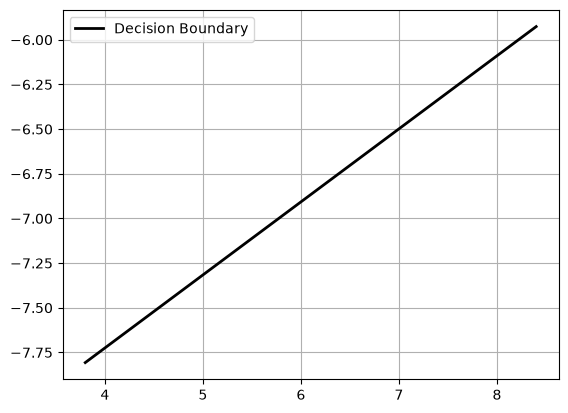

In [253]:
x_values = np.array([
    x[:,0].min()-0.5,
    x[:,0].max()+0.5
])

# w0 + w1*x + w2*y = 0
y_values = -(w0 + w1*x_values) / w2

plt.plot(
    x_values,
    y_values,
    color='black',
    linewidth=2,
    label='Decision Boundary'
)

plt.legend()
plt.grid(True)
plt.show()

### Задача 2: Предсказание диабета у женщин (Работа с метриками)

- **Датасет:** На Kaggle по запросу **"Pima Indians Diabetes Database"** (`diabetes.csv`). Целевая переменная — `Outcome` (1 — есть диабет, 0 — нет).
- **Что нужно сделать:**
    1. Исследовать данные. Есть ли пропущенные или аномальные значения (например, нулевое кровяное давление или нулевой BMI)? Заполнить их медианой.
    2. Разбить выборку на train/test. **Важно:** применить `StandardScaler`, так как логистическая регрессия очень чувствительна к разному масштабу признаков (например, возраст до 100, а уровень инсулина до 800).
    3. Обучить `LogisticRegression`.
    4. Построить матрицу ошибок (`confusion_matrix`).
    5. Посчитать `precision_score`, `recall_score` и `f1_score`.
    6. **Творческое задание:** Нужно обнаружить как можно больше больных, даже если ради этого придется отправить здоровых на доп. обследование. Изменить порог вероятности (используя метод `model.predict_proba`) с 0.5 до 0.3. Посмотреть, как изменились метрики `Precision` и `Recall`.

In [254]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("diabetes.csv")

df = df.dropna()
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


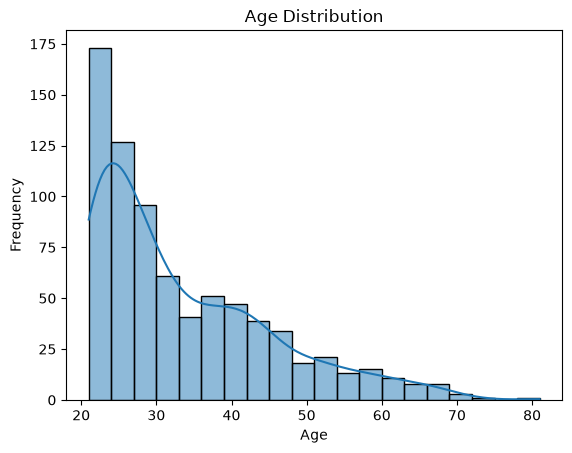

In [255]:
sns.histplot(df["Age"], bins = 20, kde = True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<Axes: >

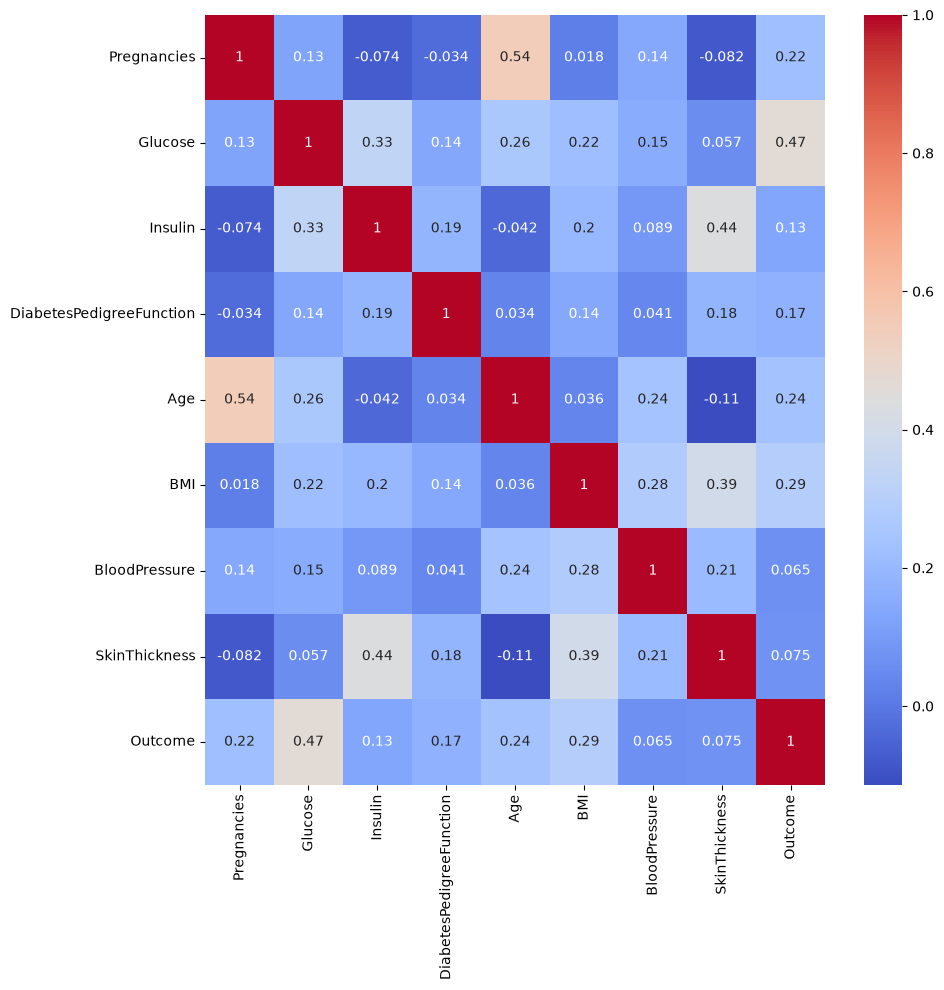

In [256]:
plt.figure(figsize = (10, 10))
corr = df[["Pregnancies", "Glucose", "Insulin", "DiabetesPedigreeFunction", "Age", "BMI", "BloodPressure", "SkinThickness", "Outcome"]].corr()
sns.heatmap(corr, annot = True, cmap = "coolwarm")

In [257]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [258]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [259]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [260]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(solver='lbfgs', max_iter=200)

lr_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [261]:
predictions = lr_model.predict_proba(X_test_scaled)[:, 1]
predictions = (predictions >= 0.3).astype(int)

print("Predictions: ", predictions)
print("Actual: ", y_test)

Predictions:  [0 0 0 0 1 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 1 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 1 1 0 1 0 0]
Actual:  668    0
324    0
624    0
690    0
473    0
      ..
355    1
534    0
344    0
296    1
462    0
Name: Outcome, Length: 154, dtype: int64


In [262]:
train_accuracy = lr_model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_accuracy)

test_accuracy = lr_model.score(X_test_scaled, y_test)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.7703583061889251
Test Accuracy: 0.7532467532467533


In [263]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print(confusion_matrix(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1-Score:", f1_score(y_test, predictions))

[[64 35]
 [13 42]]
Precision: 0.5454545454545454
Recall: 0.7636363636363637
F1-Score: 0.6363636363636364


### Задача 3: Детекция спам-сообщений (Логистическая регрессия на текстах)

Логистическая регрессия в связке с простым кодированием текста — мощнейший и очень быстрый базовый вариант (baseline) для анализа текстов.

- **Датасет:** Kaggle **"SMS Spam Collection Dataset"** (`spam.csv`).
- **Что нужно сделать:**
    1. Переведите целевой признак в числа (`spam` -> 1, `ham` -> 0).
    2. Для превращения текста в матрицу чисел используйте `TfidfVectorizer` из `sklearn.feature_extraction.text`. Он превратит каждое сообщение в вектор, где столбцы — это уникальные слова, а значения — их важность.
    3. Разбейте данные на тренировочные и тестовые.
    4. Обучите `LogisticRegression` (можно добавить L1-регуляризацию `penalty='l1', solver='liblinear'`, чтобы занулить веса у неважных слов).
    5. Посмотрите на самые большие положительные и самые маленькие отрицательные коэффициенты модели. Выведите слова, которым они соответствуют. Вы увидите, какие именно слова для модели являются главными маркерами спама (например: "free", "win", "cash").

In [264]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('spam.csv',delimiter=',',encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [265]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],axis=1,inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


Text(0.5, 1.0, 'Number of ham and spam messages')

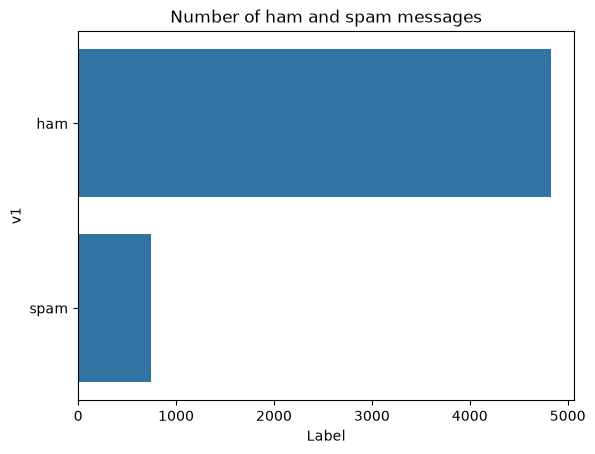

In [266]:
sns.countplot(df.v1)
plt.xlabel('Label')
plt.title('Number of ham and spam messages')

In [267]:
from sklearn.preprocessing import LabelEncoder

X = df.v2
Y = df.v1
le = LabelEncoder()
Y = le.fit_transform(Y)

In [268]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)

In [269]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [270]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(l1_ratio=1, solver='liblinear', max_iter=200)

model.fit(X_train, y_train)

,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticn

In [271]:
predictions = model.predict(X_test)

print("Predictions: ", predictions)
print("Actual: ", y_test)

Predictions:  [0 0 1 ... 0 0 0]
Actual:  [0 0 1 ... 0 0 1]


In [272]:
train_accuracy = model.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

test_accuracy = model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9715054969710568
Test Accuracy: 0.9632286995515695


In [275]:
import numpy as np

coef = model.coef_[0]

feature_names = vectorizer.get_feature_names_out()

top_n = 20

top_positive_idx = np.argsort(coef)[-top_n:][::-1]

print("Spam markers:")
for idx in top_positive_idx:
    print(f"{feature_names[idx]:15} {coef[idx]:.4f}")

top_negative_idx = np.argsort(coef)[:top_n]

print("\nHAM markers:")
for idx in top_negative_idx:
    print(f"{feature_names[idx]:15} {coef[idx]:.4f}")

Spam markers:
txt             15.4787
claim           12.8511
uk              12.3411
50              11.4502
www             10.9396
service         9.2758
150p            9.2357
call            8.5605
mobile          8.4318
http            8.2757
text            7.5399
reply           6.9465
stop            6.7761
18              6.3088
ringtone        6.2865
chat            5.9251
free            5.7127
per             5.6647
cash            5.3527
code            5.2999

HAM markers:
me              -8.6046
my              -5.7012
can             -3.9483
ll              -3.4001
gt              -3.1496
at              -2.7866
ok              -2.5612
later           -2.2057
lt              -2.1436
that            -2.0438
so              -1.9571
am              -1.8268
sir             -1.6034
sorry           -1.5740
you             -1.4892
how             -1.3805
but             -1.3603
what            -1.1100
going           -1.1080
he              -1.0902
